In [2]:
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import csv

In [3]:
input_json_reviews = '../data/json/yelp_academic_dataset_review.json'
output_csv_reviews = '../data/csv/yelp_academic_dataset_review.csv'
input_json_business = '../data/json/yelp_academic_dataset_business.json'
output_csv_business = '../data/csv/yelp_academic_dataset_business.csv'

def convertir_json_reviews_to_csv(input_file: str, output_file: str):
    """
    Lee un archivo NDJSON y lo convierte a CSV usando Polars.
    
    Args:
        input_file (str): Ruta al archivo JSON original (Yelp).
        output_file (str): Ruta donde se guardará el CSV resultante.
    """
    (
        pl.scan_ndjson(input_file)
        .drop(['cool', 'funny', 'useful'])
        .drop_nulls()
        .with_columns(pl.col('text').str.len_chars().alias('num_chars')
                      ,pl.col('text').str.split(' ').list.len().alias('word_count'))
        .sink_csv(output_file)
    )

def convertir_json_business_to_csv(input_file: str, output_file: str):
    """
    Lee un archivo NDJSON y lo convierte a CSV usando Polars.
    
    Args:
        input_file (str): Ruta al archivo JSON original (Yelp).
        output_file (str): Ruta donde se guardará el CSV resultante.
    """
    (
        pl.scan_ndjson(input_file)
        .drop(['attributes', 'hours'])
        .drop_nulls()
        .sink_csv(output_file)
        
    )

def merge_reviews_with_business(reviews_csv: str, business_csv: str):
    """
    Lee dos archivos csv que se corresponden a los de las funciones anteriores y 
    mapea los valores de los business con cada reseña

    Args:
        reviews_csv (str): Ruta al archivo CSV asociado a las reseñas
        business_csv (str): Ruta al archivo CSV asociado a los business
    """
    reviews = pl.scan_csv(reviews_csv)
    business = pl.scan_csv(business_csv)

    merged = (
    reviews
    .join(
        business.select(['business_id', 'categories', 'city', 'state', 'stars']),
        on='business_id',
        how='left',
        suffix='_business'
        )
    ).drop_nulls()

    merged.sink_csv('../data/csv/yelp_reviews_with_business.csv')

convertir_json_reviews_to_csv(input_json_reviews, output_csv_reviews)
convertir_json_business_to_csv(input_json_business, output_csv_business)
merge_reviews_with_business(output_csv_reviews, output_csv_business)

---Ejemplos---
shape: (5, 12)
┌─────────────┬─────────────┬─────────────┬───────┬───┬─────────────┬────────┬───────┬─────────────┐
│ review_id   ┆ user_id     ┆ business_id ┆ stars ┆ … ┆ categories  ┆ city   ┆ state ┆ stars_busin │
│ ---         ┆ ---         ┆ ---         ┆ ---   ┆   ┆ ---         ┆ ---    ┆ ---   ┆ ess         │
│ str         ┆ str         ┆ str         ┆ f64   ┆   ┆ str         ┆ str    ┆ str   ┆ ---         │
│             ┆             ┆             ┆       ┆   ┆             ┆        ┆       ┆ f64         │
╞═════════════╪═════════════╪═════════════╪═══════╪═══╪═════════════╪════════╪═══════╪═════════════╡
│ PiitKajcio3 ┆ Dx_YWaJx1qJ ┆ SKgD0jRWVKk ┆ 5.0   ┆ … ┆ Restaurants ┆ Tucson ┆ AZ    ┆ 3.5         │
│ 4HCc6qMDRZw ┆ -YSG9z2NyEQ ┆ 3NqOtSs3VFA ┆       ┆   ┆ , Breakfast ┆        ┆       ┆             │
│             ┆             ┆             ┆       ┆   ┆ & Brunc…    ┆        ┆       ┆             │
│ r7mKyEcShrH ┆ s_C3YVr2PQ0 ┆ -cE9GrThz6H ┆ 1.0   ┆ … ┆ Break

/tmp/ipykernel_10319/119217738.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()


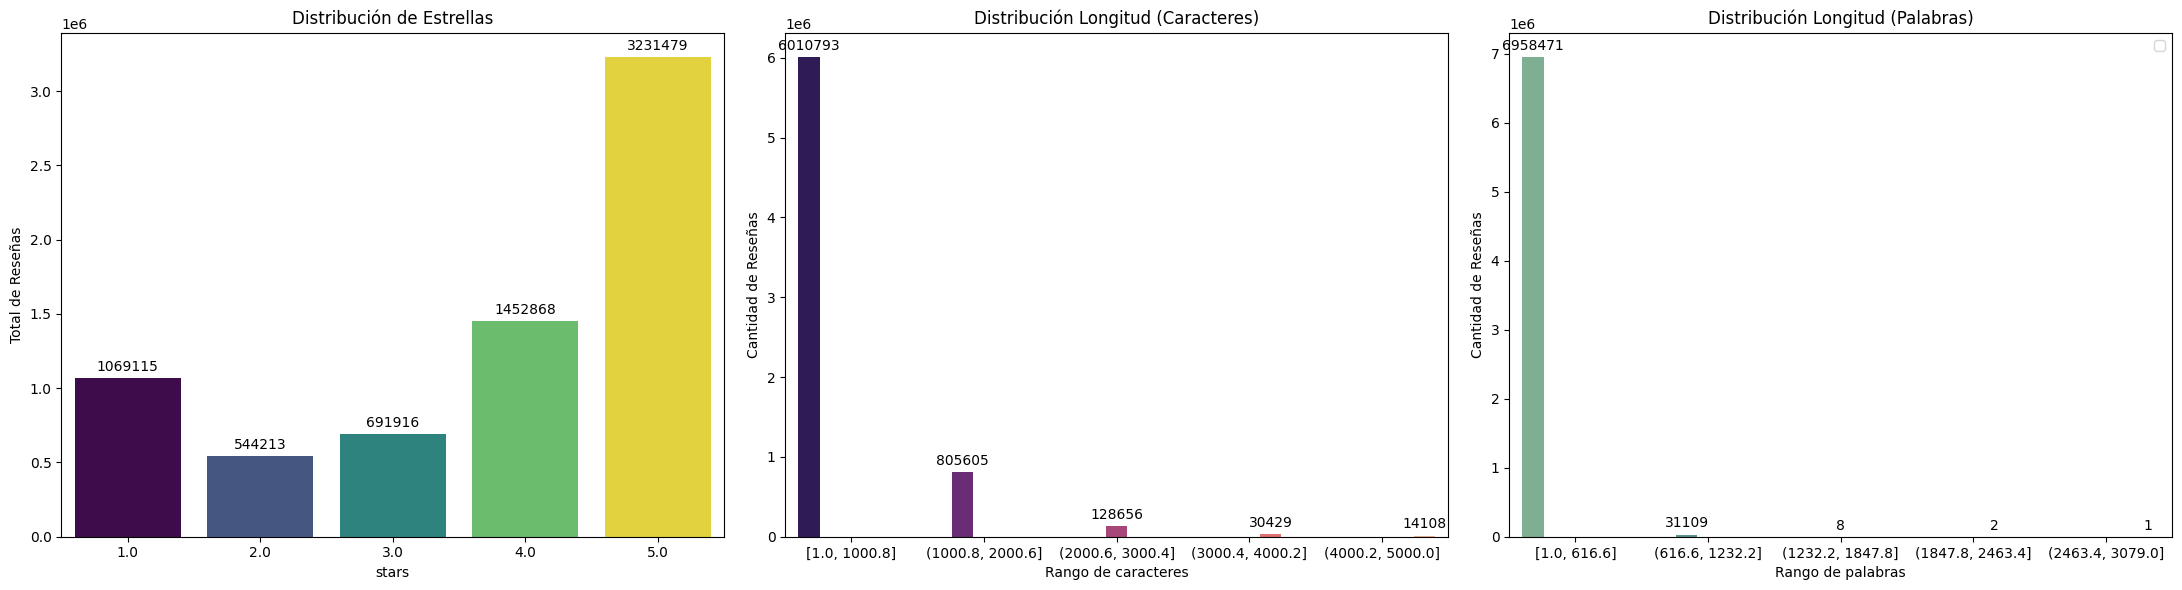

ANÁLISIS DE CATEGORÍAS
Categorías individuales únicas:           1,302
Categorías con >=2000 reviews:   621
Categorías con < 2000 reviews: 681

Top 25 categorías:
shape: (25, 2)
┌────────────────────────┬───────────┐
│ cat_list               ┆ n_reviews │
│ ---                    ┆ ---       │
│ str                    ┆ u32       │
╞════════════════════════╪═══════════╡
│ American (Traditional) ┆ 1011646   │
│ American (New)         ┆ 984540    │
│ Breakfast & Brunch     ┆ 867430    │
│ Sandwiches             ┆ 691864    │
│ Seafood                ┆ 620247    │
│ …                      ┆ …         │
│ Wine & Spirits         ┆ 232960    │
│ Beer                   ┆ 232960    │
│ Sushi Bars             ┆ 224849    │
│ Chinese                ┆ 221063    │
│ Pubs                   ┆ 218891    │
└────────────────────────┴───────────┘


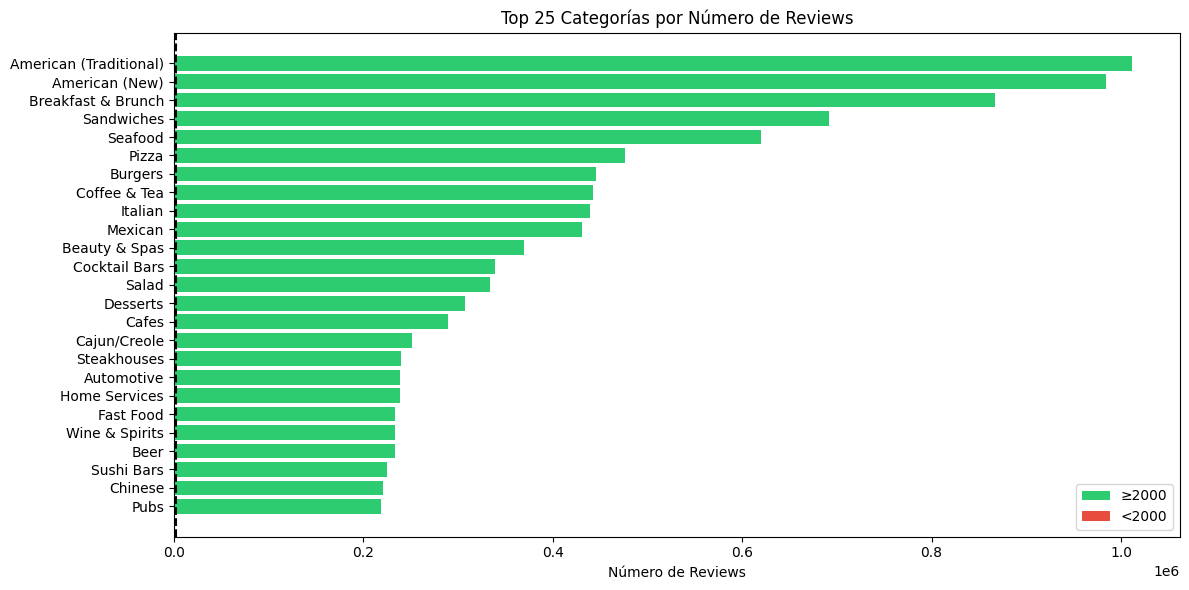

LONGITUD DE TEXTO POR CATEGORÍA
shape: (25, 6)
┌────────────────────────┬───────────┬────────────┬───────────┬────────────┬───────────────────┐
│ cat_list               ┆ n_reviews ┆ avg_words  ┆ med_words ┆ avg_chars  ┆ pct_short_reviews │
│ ---                    ┆ ---       ┆ ---        ┆ ---       ┆ ---        ┆ ---               │
│ str                    ┆ u32       ┆ f64        ┆ f64       ┆ f64        ┆ f64               │
╞════════════════════════╪═══════════╪════════════╪═══════════╪════════════╪═══════════════════╡
│ American (Traditional) ┆ 1011646   ┆ 102.671195 ┆ 73.0      ┆ 550.63332  ┆ 0.047114          │
│ American (New)         ┆ 984540    ┆ 109.550984 ┆ 78.0      ┆ 591.999128 ┆ 0.044757          │
│ Breakfast & Brunch     ┆ 867430    ┆ 98.651122  ┆ 70.0      ┆ 533.299354 ┆ 0.051672          │
│ Sandwiches             ┆ 691864    ┆ 93.344328  ┆ 68.0      ┆ 501.418756 ┆ 0.053869          │
│ Seafood                ┆ 620247    ┆ 102.321575 ┆ 72.0      ┆ 551.704919 ┆ 0.0

/tmp/ipykernel_10319/3985453969.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


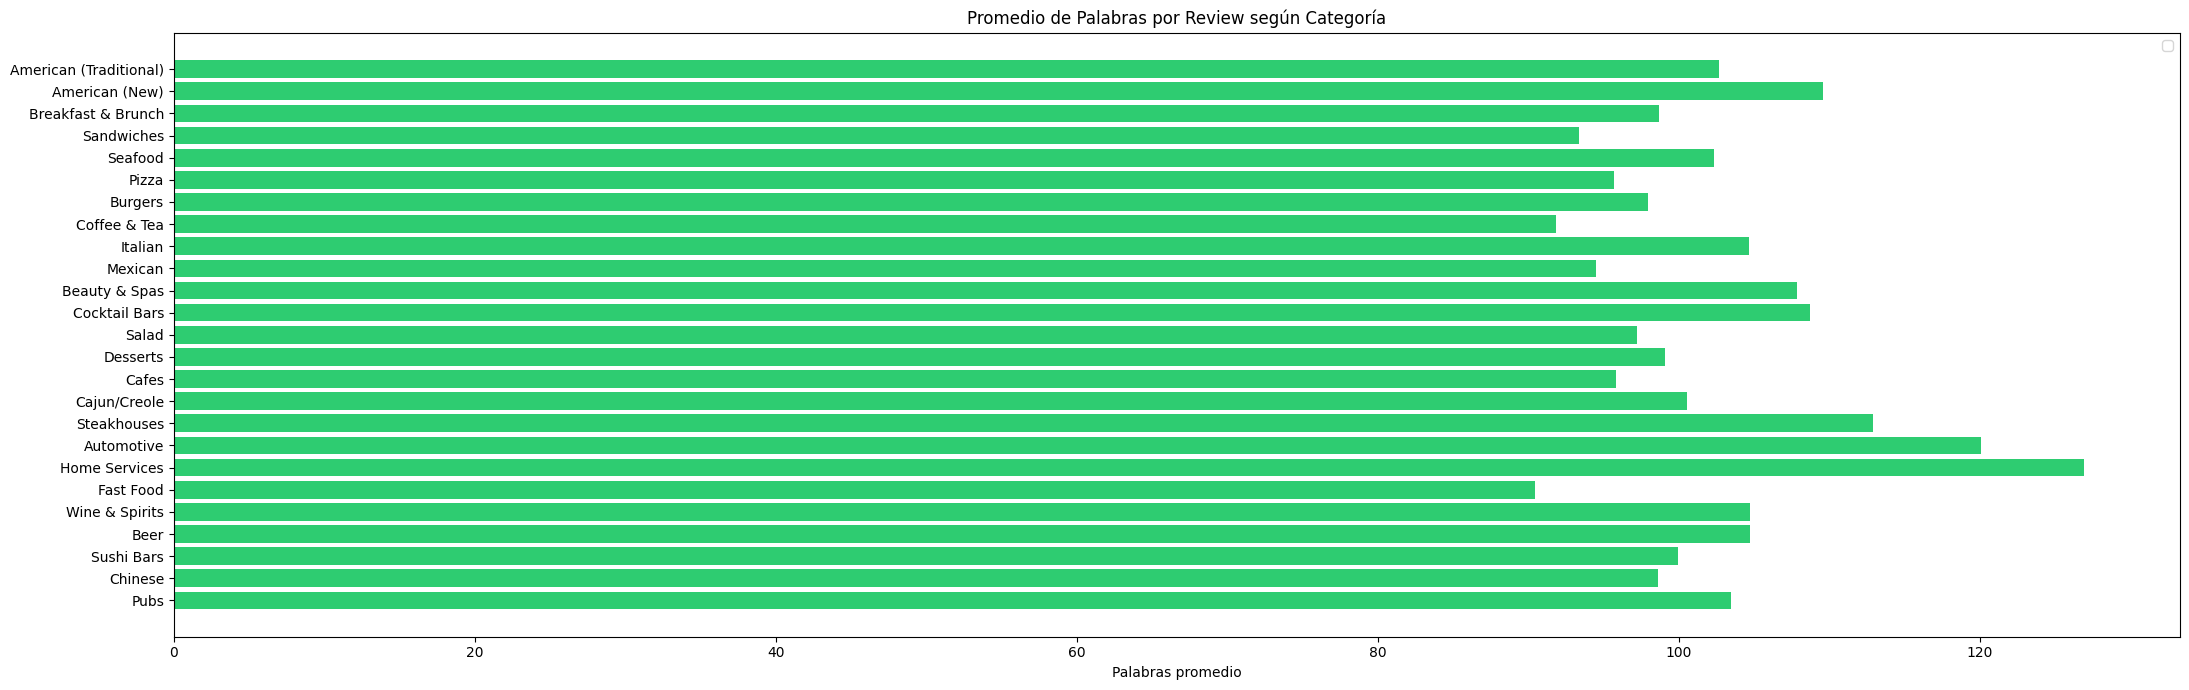

DISTRIBUCIÓN DE ESTRELLAS POR CATEGORÍA
shape: (25, 6)
┌────────────────────────┬───────────┬───────────┬───────────────┬───────────────┬─────────────┐
│ cat_list               ┆ n_reviews ┆ avg_stars ┆ pct_positivas ┆ pct_negativas ┆ pct_neutras │
│ ---                    ┆ ---       ┆ ---       ┆ ---           ┆ ---           ┆ ---         │
│ str                    ┆ u32       ┆ f64       ┆ f64           ┆ f64           ┆ f64         │
╞════════════════════════╪═══════════╪═══════════╪═══════════════╪═══════════════╪═════════════╡
│ American (Traditional) ┆ 1011646   ┆ 3.668343  ┆ 0.639705      ┆ 0.231615      ┆ 0.12868     │
│ American (New)         ┆ 984540    ┆ 3.841483  ┆ 0.690204      ┆ 0.187533      ┆ 0.122263    │
│ Breakfast & Brunch     ┆ 867430    ┆ 3.879319  ┆ 0.703974      ┆ 0.182931      ┆ 0.113095    │
│ Sandwiches             ┆ 691864    ┆ 3.851399  ┆ 0.69676       ┆ 0.192529      ┆ 0.110711    │
│ Seafood                ┆ 620247    ┆ 3.851529  ┆ 0.692726      ┆ 0.190

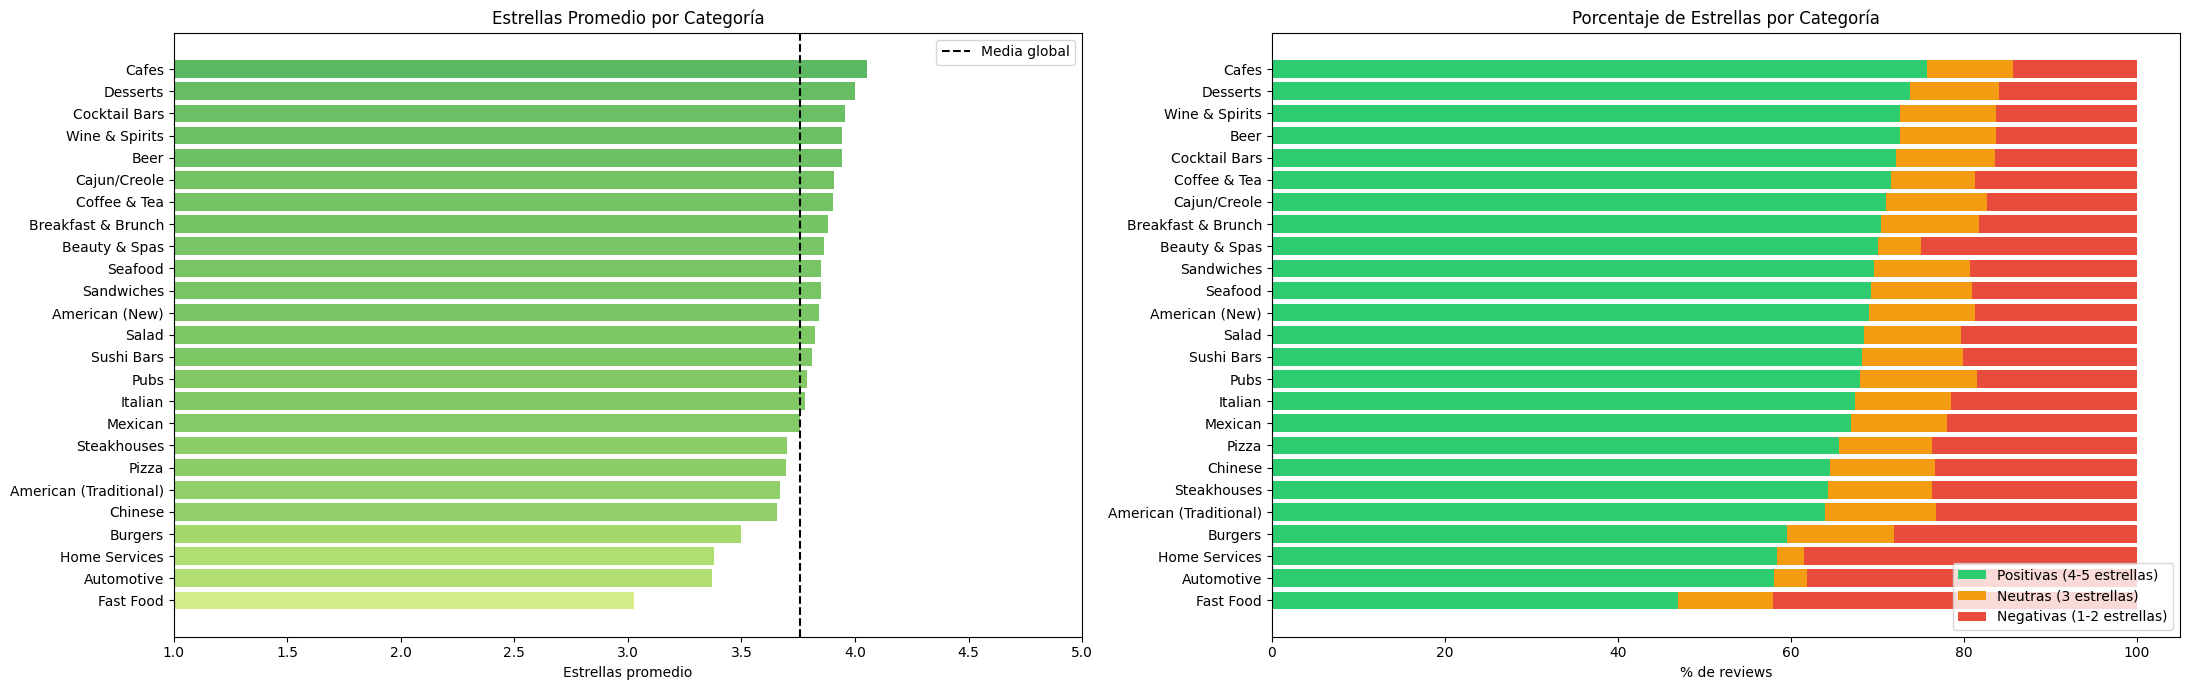

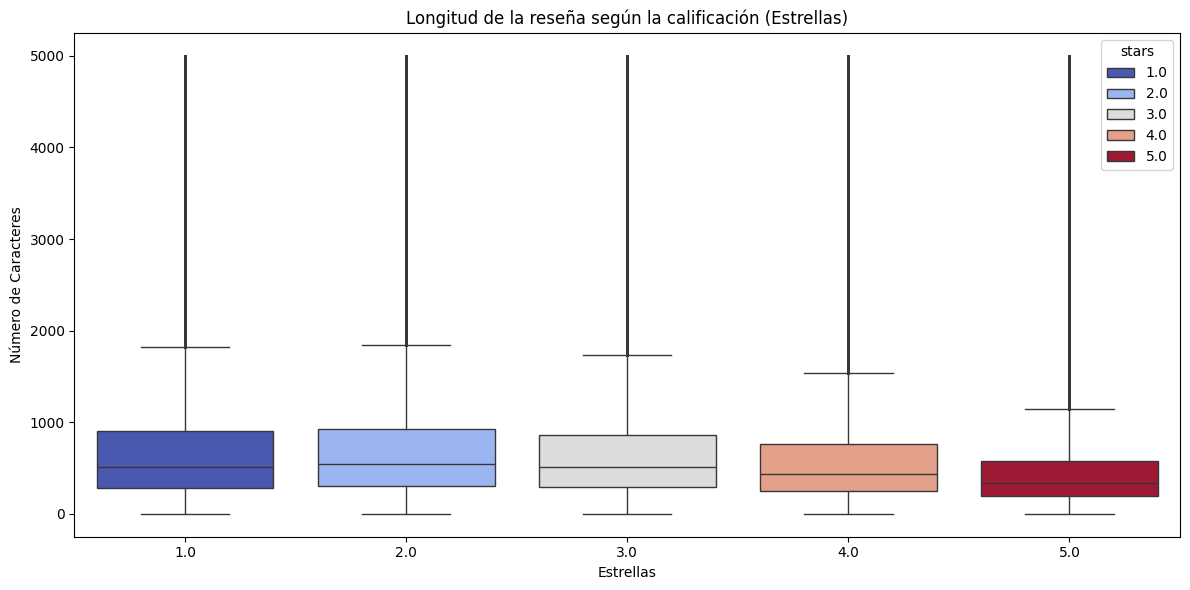

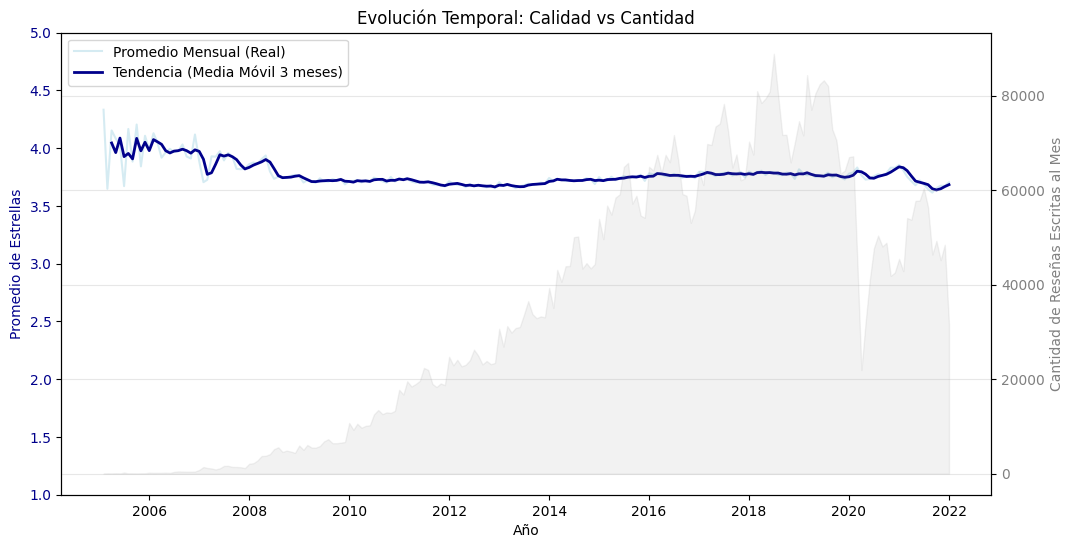

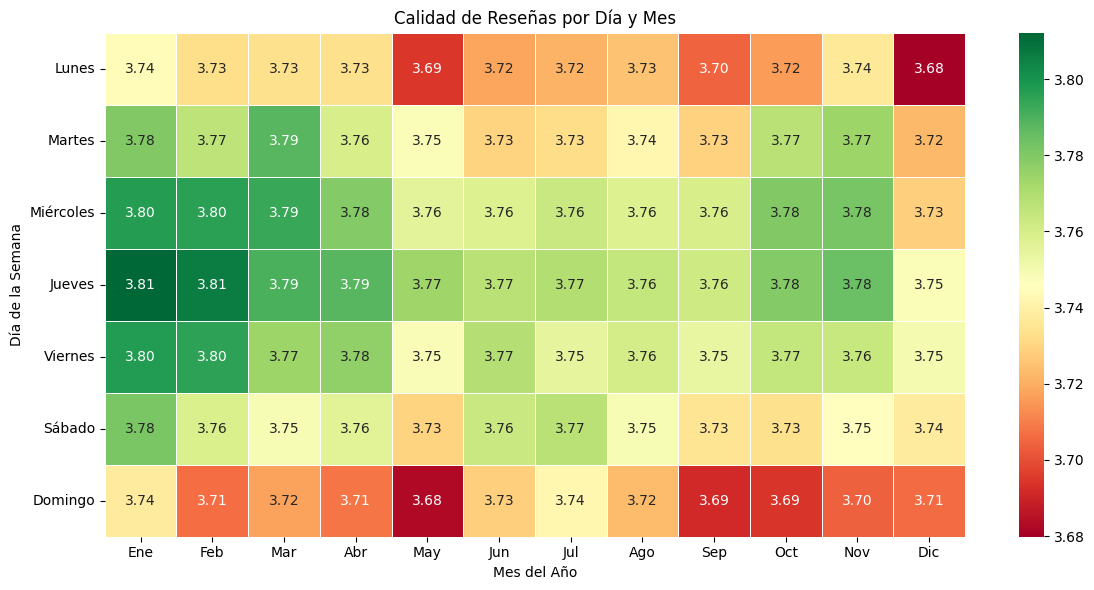

In [70]:
csv_reviews_business = '../data/csv/yelp_reviews_with_business.csv'
EXCLUDE_CATEGORIES = {
    'Restaurants', 'Food', 'Nightlife', 'Bars',
    'Event Planning & Services', 'Shopping',
    'Arts & Entertainment', 'Hotels & Travel', 'Specialty Food',
}

def analisis_exploratorio(csv: str):
    """
    Realiza un EDA sobre un dataset en formato csv, realizando un sanity check, 
    la distribución de las variables y buscando patrones multivariables

    Args:
        csv (str): Ruta del fichero csv
    """
    q = pl.scan_csv(csv, ignore_errors=True)
    
    # Mostrar ejemplos
    print("---Ejemplos---")
    print(q.head(5).collect())
    
    # Contar nulos
    nulls = q.select(pl.all().null_count()).collect(engine="streaming")
    print("--- Nulos por columna ---")
    print(nulls)
    
    # Describe
    print("\n--- Estadísticas Descriptivas ---")
    numeric_cols = q.select(pl.col(pl.Int64, pl.Float64)).collect_schema().names()
    describe_df = q.select(numeric_cols).describe()
    print(describe_df)

    q = q.with_columns(
        pl.col("date").str.to_datetime(strict=False)
    )
    
    operaciones = [
        pl.len().alias("total_reviews"),
        pl.col("business_id").n_unique().alias("negocios_unicos"),
        pl.col("user_id").n_unique().alias("usuarios_unicos"),
        pl.col("date").min().alias("fecha_inicio"),
        pl.col("date").max().alias("fecha_fin")
    ]
    
    df_resultado = q.select(operaciones).collect(engine="streaming")
    
    res = df_resultado.row(0)
    print("\n--- RESULTADOS ---")
    print(f"Total de Reviews:    {res[0]:,}")
    print(f"Negocios Únicos:     {res[1]:,}")
    print(f"Usuarios Únicos:     {res[2]:,}")
    print(f"Periodo:   {res[3]} - {res[4]}")
    
    dias = (res[4] - res[3]).days
    print(f"Duración: {dias} días ({dias/365:.1f} años)\n")

    analisis_univariable(csv)
    analisis_categorias(csv, top_n=25, exclude=EXCLUDE_CATEGORIES)
    analisis_texto_por_categoria(csv, top_n=25, exclude=EXCLUDE_CATEGORIES)
    analisis_estrellas_por_categoria(csv, top_n=25, exclude=EXCLUDE_CATEGORIES)
    analisis_multivariable(csv)
    
analisis_exploratorio(csv_reviews_business)

In [54]:
def analisis_univariable(csv_path: str):
    """
    Realiza un pequeño análisis estadístico sobre las variables numéricas
    (stars, num_chars, word_count) para ver su distribución.
    Args:
        csv_path (str): Ruta al fichero csv que contiene las reviews
    """
    stats = (
        pl.scan_csv(csv_path)
        .select(['stars', 'num_chars', 'word_count'])
        .collect()
    )

    series_chars = stats.get_column('num_chars')
    series_words = stats.get_column('word_count')

    df_stars = (
        stats.group_by('stars')
        .len()
        .sort('stars')
        .with_columns(
            (pl.col('len') / pl.col('len').sum() * 100).alias('percentage')
        )
    )
    del stats 

    def make_hist(series, bin_count=5):
        df = series.hist(bin_count=bin_count)
        col = 'category' if 'category' in df.columns else 'break_point'
        return df.rename({col: 'rango', 'count': 'total'})

    df_hist_chars = make_hist(series_chars)
    del series_chars

    df_hist_words = make_hist(series_words)

    print("Resumen Estrellas:\n", df_stars)
    print("\nResumen Rangos Caracteres:\n", df_hist_chars)
    print("\nResumen Rangos Palabras:\n", df_hist_words)
    print(f"\nMedia palabras:    {series_words.mean():.1f}")
    print(f"Mediana palabras:  {series_words.median():.1f}")
    print(f"Reviews < 20 palabras:    {(series_words < 20).sum():,} "
          f"({(series_words < 20).sum() / len(series_words) * 100:.2f}%)")
    print(f"Reviews < 10 palabras: {(series_words < 10).sum():,} "
          f"({(series_words < 10).sum() / len(series_words) * 100:.2f}%)")
    del series_words

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    sns.barplot(data=df_stars.to_pandas(), x='stars', y='len',
                hue='stars', palette='viridis', ax=axes[0], legend=False)
    axes[0].set_title("Distribución de Estrellas")
    axes[0].set_ylabel("Total de Reseñas")
    del df_stars

    sns.barplot(data=df_hist_chars.to_pandas(), x='rango', y='total',
                hue='rango', palette='magma', ax=axes[1], legend=False)
    axes[1].set_title("Distribución Longitud (Caracteres)")
    axes[1].set_xlabel("Rango de caracteres")
    axes[1].set_ylabel("Cantidad de Reseñas")
    del df_hist_chars

    sns.barplot(data=df_hist_words.to_pandas(), x='rango', y='total',
                hue='rango', palette='crest', ax=axes[2], legend=False)
    axes[2].set_title("Distribución Longitud (Palabras)")
    axes[2].set_xlabel("Rango de palabras")
    axes[2].set_ylabel("Cantidad de Reseñas")
    axes[2].legend()
    del df_hist_words

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, fmt='%d', padding=3)

    plt.tight_layout()
    plt.show()

In [55]:
def analisis_multivariable(csv_path: str):
    """
    Realiza un análisis sobre varios conjuntos de variables para entender si hay tendencias y correlaciones entre estos

    Args:
        csv_path (str): Ruta al fichero csv que contiene las reviews
    """
    q = pl.scan_csv(csv_path)

    stars_vs_chars_boxplot(q)
    analisis_temporal_stars(q)
    analisis_estacionalidad_reseñas(q)
    

In [56]:
def analisis_categorias(csv_path: str, top_n: int = 25, min_reviews: int = 2000, exclude: set = EXCLUDE_CATEGORIES):
    """
    Analiza la distribución de las categorías de negocio.
    Args:
        csv_path: Ruta al CSV mergeado (reviews + business)
        top_n: Cuántas categorías mostrar en los gráficos
        min_reviews: Umbral mínimo de reviews para topic modeling
    """
    cat_counts = (
        pl.scan_csv(csv_path, ignore_errors=True)
        .filter(pl.col('categories').is_not_null())
        .select('categories')
        .with_columns(pl.col('categories').str.split(', ').alias('cat_list'))
        .explode('cat_list')
        .with_columns(pl.col('cat_list').str.strip_chars())
        .filter(pl.col('cat_list').str.len_chars() > 0)
        .filter(~pl.col('cat_list').is_in(list(exclude)))
        .group_by('cat_list')
        .agg(pl.len().alias('n_reviews'))
        .sort('n_reviews', descending=True)
        .collect()
    )

    total_cats  = cat_counts.height
    viable_cats = cat_counts.filter(pl.col('n_reviews') >= min_reviews).height

    print("=" * 60)
    print("ANÁLISIS DE CATEGORÍAS")
    print("=" * 60)
    print(f"Categorías individuales únicas:           {total_cats:,}")
    print(f"Categorías con >={min_reviews} reviews:   {viable_cats:,}")
    print(f"Categorías con < {min_reviews} reviews: {total_cats - viable_cats:,}")
    print(f"\nTop {top_n} categorías:")
    print(cat_counts.head(top_n))

    top_df        = cat_counts.head(top_n).to_pandas()
    del cat_counts

    plt.figure(figsize=(12, 6))

    colors = ['#2ecc71' if v >= min_reviews else '#e74c3c' for v in top_df['n_reviews']]
    plt.barh(top_df['cat_list'][::-1], top_df['n_reviews'][::-1], color=colors[::-1])
    plt.axvline(x=min_reviews, color='black', linestyle='--',
                    linewidth=1.5)
    plt.title(f"Top {top_n} Categorías por Número de Reviews")
    plt.xlabel("Número de Reviews")
    plt.legend(handles=[
        Patch(facecolor='#2ecc71', label=f'≥{min_reviews}'),
        Patch(facecolor='#e74c3c', label=f'<{min_reviews}')
    ], loc='lower right')
    del top_df, colors

    plt.tight_layout()
    plt.show()

In [69]:
def analisis_texto_por_categoria(csv_path: str, top_n: int = 20, min_reviews: int = 2000, exclude: set = EXCLUDE_CATEGORIES):
    """
    Analiza la longitud media de las reviews por categoría.
    Categorías con reviews muy cortas generarán topics poco coherentes en LDA/BERTopic.
    Args:
        csv_path: Ruta al CSV mergeado
        top_n: Número de categorías a mostrar
        min_reviews: Mismo umbral que en analisis_categorias
    """
    cat_text_stats = (
        pl.scan_csv(csv_path, ignore_errors=True)
        .filter(pl.col('categories').is_not_null())
        .select(['categories', 'num_chars', 'word_count'])
        .with_columns(pl.col('categories').str.split(', ').alias('cat_list'))
        .explode('cat_list')
        .with_columns(pl.col('cat_list').str.strip_chars())
        .filter(pl.col('cat_list').str.len_chars() > 0)
        .filter(~pl.col('cat_list').is_in(list(exclude)))
        .group_by('cat_list')
        .agg([
            pl.len().alias('n_reviews'),
            pl.col('word_count').mean().alias('avg_words'),
            pl.col('word_count').median().alias('med_words'),
            pl.col('num_chars').mean().alias('avg_chars'),
            (pl.col('word_count') < 20).mean().alias('pct_short_reviews')
        ])
        .filter(pl.col('n_reviews') >= min_reviews)
        .sort('n_reviews', descending=True)
        .collect()
    )

    print("=" * 60)
    print("LONGITUD DE TEXTO POR CATEGORÍA")
    print("=" * 60)
    print(cat_text_stats.head(top_n))

    plot_df = cat_text_stats.head(top_n).to_pandas().sort_values('n_reviews')
    del cat_text_stats

    plt.figure(figsize=(22, 7))

    colors = ['#e74c3c' if v < 40 else '#2ecc71' for v in plot_df['avg_words']]
    plt.barh(plot_df['cat_list'], plot_df['avg_words'], color=colors)
    plt.title("Promedio de Palabras por Review según Categoría")
    plt.xlabel("Palabras promedio")
    plt.legend()
    del colors
    del plot_df


    plt.tight_layout()
    plt.show()

In [63]:
def analisis_estrellas_por_categoria(csv_path: str, top_n: int = 20, min_reviews: int = 2000, exclude: set = EXCLUDE_CATEGORIES):
    """
    Analiza la distribución de estrellas por categoría.
    Un sesgo muy positivo en una categoría significa que los topics negativos
    estarán subrepresentados en los modelos entrenados sobre ella.
    Args:
        csv_path: Ruta al CSV mergeado
        top_n: Número de categorías a mostrar
        min_reviews: Mismo umbral que en analisis_categorias
    """
    q = pl.scan_csv(csv_path, ignore_errors=True).filter(pl.col('categories').is_not_null())

    df = (
        q.select(['categories', 'stars'])
        .collect()
        .with_columns(pl.col('categories').str.split(', ').alias('cat_list'))
        .explode('cat_list')
        .with_columns(pl.col('cat_list').str.strip_chars())
        .filter(pl.col('cat_list').str.len_chars() > 0)
        .filter(~pl.col('cat_list').is_in(list(exclude)))

    )

    cat_stars = (
        df.group_by('cat_list')
        .agg([
            pl.len().alias('n_reviews'),
            pl.col('stars').mean().alias('avg_stars'),
            (pl.col('stars') >= 4).mean().alias('pct_positivas'),
            (pl.col('stars') <= 2).mean().alias('pct_negativas'),
            (pl.col('stars') == 3).mean().alias('pct_neutras'),
        ])
        .filter(pl.col('n_reviews') >= min_reviews)
        .sort('n_reviews', descending=True)
    )

    print("=" * 60)
    print("DISTRIBUCIÓN DE ESTRELLAS POR CATEGORÍA")
    print("=" * 60)
    print(cat_stars.head(top_n))
    print("\n→ pct_negativas < 0.10 = topics negativos subrepresentados, cuidado al interpretar")

    plot_df = cat_stars.head(top_n).to_pandas().sort_values('avg_stars')

    fig, axes = plt.subplots(1, 2, figsize=(22, 7))

    colors = plt.cm.RdYlGn([v / 5 for v in plot_df['avg_stars']])
    axes[0].barh(plot_df['cat_list'], plot_df['avg_stars'], color=colors)
    axes[0].axvline(x=plot_df['avg_stars'].mean(), color='black', 
                    linestyle='--', linewidth=1.5, label='Media global')
    axes[0].set_xlim(1, 5)
    axes[0].set_title("Estrellas Promedio por Categoría")
    axes[0].set_xlabel("Estrellas promedio")
    axes[0].legend()

    plot_df_sorted = plot_df.sort_values('pct_positivas', ascending=True)
    axes[1].barh(plot_df_sorted['cat_list'], plot_df_sorted['pct_positivas'] * 100,
                 label='Positivas (4-5 estrellas)', color='#2ecc71')
    axes[1].barh(plot_df_sorted['cat_list'], plot_df_sorted['pct_neutras'] * 100,
                 left=plot_df_sorted['pct_positivas'] * 100,
                 label='Neutras (3 estrellas)', color='#f39c12')
    axes[1].barh(plot_df_sorted['cat_list'], plot_df_sorted['pct_negativas'] * 100,
                 left=(plot_df_sorted['pct_positivas'] + plot_df_sorted['pct_neutras']) * 100,
                 label='Negativas (1-2 estrellas)', color='#e74c3c')
    axes[1].set_title("Porcentaje de Estrellas por Categoría")
    axes[1].set_xlabel("% de reviews")
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

In [59]:
def stars_vs_chars_boxplot(df: pl.DataFrame):
    """
    Realiza un boxplot de stars vs num_chars para ver la relación entre estos

    Args:
        df (DataFrame): Dataframe que contiene todas las reviews
    """
    df_stars_chars = (df.select(['stars', 'num_chars']).collect().to_pandas())
    
    plt.figure(figsize=(12, 6))
    # ¿Debería mostrar los outliers? En comparación con todas las reseñas son muy pocos pero ensucian el gráfico bastante
    sns.boxplot(data=df_stars_chars, x='stars', y='num_chars', hue='stars', palette='coolwarm', fliersize=1)
    plt.title("Longitud de la reseña según la calificación (Estrellas)")
    plt.xlabel("Estrellas")
    plt.ylabel("Número de Caracteres")
    plt.tight_layout()
    plt.show()


In [60]:
def analisis_temporal_stars(df: pl.LazyFrame):
    """
    Realiza un análisis temporal a la variable stars y al número de reseñas globales
    para ver como ha ido cambiando su comportamiento a lo largo del tiempo

    Args:
        df (LazyFrame): Dataframe que contiene todas las reviews
    """
    # Primero convertir date a datetime y truncar por mes, agrupar por esta nueva columna 
    # y añadir la media de estrellas y el número de reseñas de cada mes
    df_temporal = (df.with_columns(pl.col('date').str.to_datetime())
        .with_columns(pl.col('date').dt.truncate('1mo').alias('mes_ano'))
    .group_by('mes_ano')
    .agg([pl.col('stars').mean().alias('avg_stars'), pl.len().alias('count')])
    .sort('mes_ano').collect().to_pandas())

    df_temporal['rolling_stars'] = df_temporal['avg_stars'].rolling(window=3).mean()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje Y izquierdo: Categoría de Estrellas
    sns.lineplot(data=df_temporal, x='mes_ano', y='avg_stars', ax=ax1, 
                 label='Promedio Mensual (Real)', color='lightblue', alpha=0.5)
    
    sns.lineplot(data=df_temporal, x='mes_ano', y='rolling_stars', ax=ax1, 
                 label='Tendencia (Media Móvil 3 meses)', color='darkblue', linewidth=2)

    ax1.set_ylabel('Promedio de Estrellas', color='darkblue')
    ax1.set_xlabel("Año")
    ax1.set_ylim(1, 5)
    ax1.tick_params(axis='y', labelcolor='darkblue')
    
    # Eje Y derecho: Cantidad de Reseñas
    ax2 = ax1.twinx()
    ax2.fill_between(df_temporal['mes_ano'], 0, df_temporal['count'], color='gray', alpha=0.1, label='Volumen de reseñas')
    ax2.set_ylabel('Cantidad de Reseñas Escritas al Mes', color='gray')
    ax2.set_xlabel("Año")
    ax2.tick_params(axis='y', labelcolor='gray')
    
    plt.title("Evolución Temporal: Calidad vs Cantidad")
    plt.grid(True, alpha=0.3)
    
    ax1.legend(loc='upper left')
    
    plt.show()

In [61]:
def analisis_estacionalidad_reseñas(df: pl.LazyFrame):
    """
    Realiza un mapa de calor para ver si los usuarios son más o menos 
    críticos en sus reseñas dependiendo del día de la semana y del mes

    Args:
        df (LazyFrame): Dataframe que contiene todas las reseñas
    """
    df_día_mes_estrellas = (
        df.with_columns(pl.col("date").str.to_datetime())
        .with_columns([
            pl.col("date").dt.weekday().alias("dia_num"),
            pl.col("date").dt.month().alias("mes_num")
        ])
        .group_by(["mes_num", "dia_num"])
        .agg(pl.col("stars").mean().alias("avg_stars"))
        .sort(["mes_num", "dia_num"])
        .collect()
        .to_pandas()
    )

    # Pasamos de  números a nombres los días de la semana
    mapa_dias = {1: "Lunes", 2: "Martes", 3: "Miércoles", 4: "Jueves", 5: "Viernes", 6: "Sábado", 7: "Domingo"}
    mapa_meses = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun", 
                  7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

    df_día_mes_estrellas["dia_nombre"] = df_día_mes_estrellas["dia_num"].map(mapa_dias)
    df_día_mes_estrellas["mes_nombre"] = df_día_mes_estrellas["mes_num"].map(mapa_meses)

    matriz = df_día_mes_estrellas.pivot_table(
        index="dia_nombre", 
        columns="mes_nombre", 
        values="avg_stars"
    )

    orden_dias = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
    orden_meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
    
    # Reindexamos la matriz para forzar el orden cronológico
    matriz = matriz.reindex(index=orden_dias, columns=orden_meses)

    plt.figure(figsize=(12, 6))
    
    sns.heatmap(matriz, cmap="RdYlGn", annot=True, fmt=".2f", linewidths=.5)

    plt.title("Calidad de Reseñas por Día y Mes")
    plt.xlabel("Mes del Año")
    plt.ylabel("Día de la Semana")
    
    plt.xticks(rotation=0) 
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()